# Pha 4 — Offline Evaluation & Error Analysis: Telco Customer Churn

Notebook này chạm tới `test_df` (holdout, 1055 dòng) **lần đầu tiên và duy nhất** trong toàn bộ CRISP-ML(Q)
cycle. Model đã chốt ở Pha 3: **CatBoost (tuned)**, PR-AUC (CV) = 0.6768 — xem
`src/churn_classification/final_model.py` và `docs/docs.md` Pha 3.

Quy trình: (1) refit model trên toàn bộ train pool, (2) chọn operating threshold bằng out-of-fold CV
predictions trên train pool (không dùng test set để tune threshold — đó vẫn là một dạng nhìn trộm test set),
(3) đánh giá đúng một lần trên test set, (4) error analysis trên các dự đoán sai của test set.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    fbeta_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.churn_classification.data_split import RANDOM_STATE, get_split
from src.churn_classification.final_model import build_final_pipeline
from src.churn_classification.preprocessing import compute_scale_pos_weight, split_X_y

train_df, test_df = get_split()
X_train, y_train = split_X_y(train_df)
X_test, y_test = split_X_y(test_df)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Positive rate - train: {y_train.mean():.4f}, test: {y_test.mean():.4f}")


Loading cached split from /home/tthhieu/survival-analysis/data/processed/churn_classification (created earlier). Delete this folder and re-run to regenerate with current TEST_SIZE/RANDOM_STATE.
X_train: (5977, 19), X_test: (1055, 19)
Positive rate - train: 0.2659, test: 0.2654


## 1. Refit model cuối cùng trên toàn bộ train pool

Ở Pha 3, model chỉ từng được fit trên 4/5 fold mỗi lần (trong CV). Giờ fit một lần trên **toàn bộ**
`train_df` để tận dụng hết dữ liệu có thể dùng — hợp lệ vì `test_df` chưa từng tham gia bất kỳ bước nào ở
Pha 2-3.


In [2]:
scale_pos_weight_train = compute_scale_pos_weight(y_train)
final_pipeline = build_final_pipeline(scale_pos_weight=scale_pos_weight_train, random_state=RANDOM_STATE)
final_pipeline.fit(X_train, y_train)
print("Da fit final_pipeline tren toan bo train pool.")


Da fit final_pipeline tren toan bo train pool.


## 2. Chọn operating threshold — dùng out-of-fold CV, không dùng test set

Threshold cũng là một tham số cần "học" từ dữ liệu — nếu chọn threshold sao cho đẹp nhất trên `test_df`,
đó vẫn là một dạng nhìn trộm test set dưới vỏ bọc khác, dù không đụng tới việc train model. Cách đúng: dùng
`cross_val_predict` để lấy xác suất **out-of-fold** trên train pool (mỗi dự đoán đến từ một model chưa từng
thấy dòng đó trong lúc fit — giống hệt cơ chế đã dùng để đo CV score ở Pha 3), quét ngưỡng trên các xác suất
này, chọn ngưỡng tối đa hóa **F2** (quyết định đã chốt ở Pha 1: recall quan trọng hơn precision vì FN đắt
hơn FP).


In [3]:
oof_pipeline = build_final_pipeline(scale_pos_weight=scale_pos_weight_train, random_state=RANDOM_STATE)
oof_proba = cross_val_predict(oof_pipeline, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

thresholds = np.linspace(0.01, 0.99, 197)
f2_by_threshold = np.array(
    [fbeta_score(y_train, (oof_proba >= t).astype(int), beta=2, zero_division=0) for t in thresholds]
)
best_idx = int(np.argmax(f2_by_threshold))
chosen_threshold = thresholds[best_idx]
print(f"Threshold chon (toi da F2 tren OOF train pool): {chosen_threshold:.3f}")
print(f"F2 tren OOF tai threshold nay: {f2_by_threshold[best_idx]:.4f}")
print(f"(Doi chieu: F2 tai threshold=0.5 mac dinh la {f2_by_threshold[np.abs(thresholds - 0.5).argmin()]:.4f})")


Threshold chon (toi da F2 tren OOF train pool): 0.295
F2 tren OOF tai threshold nay: 0.7482
(Doi chieu: F2 tai threshold=0.5 mac dinh la 0.7220)


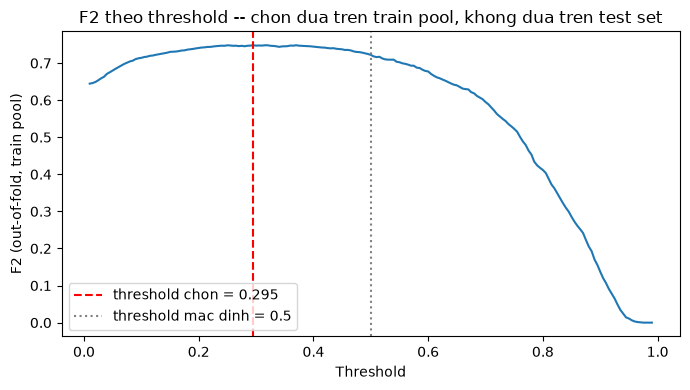

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, f2_by_threshold)
ax.axvline(chosen_threshold, color="red", linestyle="--", label=f"threshold chon = {chosen_threshold:.3f}")
ax.axvline(0.5, color="gray", linestyle=":", label="threshold mac dinh = 0.5")
ax.set_xlabel("Threshold")
ax.set_ylabel("F2 (out-of-fold, train pool)")
ax.set_title("F2 theo threshold -- chon dua tren train pool, khong dua tren test set")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Đánh giá trên holdout test set — lần đầu và duy nhất


In [5]:
test_proba = final_pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= chosen_threshold).astype(int)

test_pr_auc = average_precision_score(y_test, test_proba)
test_roc_auc = roc_auc_score(y_test, test_proba)
test_f2 = fbeta_score(y_test, test_pred, beta=2)

# Tu Pha 3 (docs/docs.md): CV mean + std qua 5 fold cho CatBoost (tuned), tinh lai
# truc tiep tu cross_validate de co ca do lech chuan, khong chi trung binh.
CV_PR_AUC_PHA3_MEAN, CV_PR_AUC_PHA3_STD = 0.6768, 0.0260
CV_ROC_AUC_PHA3_MEAN, CV_ROC_AUC_PHA3_STD = 0.8504, 0.0136

pr_auc_z = (test_pr_auc - CV_PR_AUC_PHA3_MEAN) / CV_PR_AUC_PHA3_STD
roc_auc_z = (test_roc_auc - CV_ROC_AUC_PHA3_MEAN) / CV_ROC_AUC_PHA3_STD

print(f"Test PR-AUC : {test_pr_auc:.4f}  (CV: {CV_PR_AUC_PHA3_MEAN:.4f} +/- {CV_PR_AUC_PHA3_STD:.4f}, z={pr_auc_z:+.2f})")
print(f"Test ROC-AUC: {test_roc_auc:.4f}  (CV: {CV_ROC_AUC_PHA3_MEAN:.4f} +/- {CV_ROC_AUC_PHA3_STD:.4f}, z={roc_auc_z:+.2f})")
print(f"Test F2 (threshold={chosen_threshold:.3f}): {test_f2:.4f}")

Test PR-AUC : 0.6365  (CV: 0.6768 +/- 0.0260, z=-1.55)
Test ROC-AUC: 0.8369  (CV: 0.8504 +/- 0.0136, z=-0.99)
Test F2 (threshold=0.295): 0.7493


**Đọc kết quả trung thực**: ROC-AUC test (0.8369) lệch khoảng 1 độ lệch chuẩn (z≈-0.99) so với CV mean —
hoàn toàn trong phạm vi biến động fold-to-fold bình thường đã thấy ở Pha 3, không đáng lo. **PR-AUC test
(0.6365) lệch nhiều hơn (z≈-1.55)** — thấp hơn cả fold thấp nhất từng quan sát được trong 5-fold CV ở Pha 3
(0.6505). Đây chưa phải bằng chứng model bị lỗi nghiêm trọng (z=-1.55 vẫn nằm trong 2 độ lệch chuẩn, và
PR-AUC vốn nhạy với cỡ mẫu dương nhỏ hơn ROC-AUC — test set chỉ có 280 mẫu dương so với ~1194 mẫu dương
trung bình mỗi fold train pool), nhưng đáng ghi nhận trung thực thay vì bỏ qua: hiệu năng thực tế trên dữ
liệu hoàn toàn mới có thể thấp hơn con số Pha 3 đã báo cáo một chút. Không đủ căn cứ để nghi ngờ leakage
(toàn bộ quy trình đã kiểm tra kỹ ở Pha 2-3), nhiều khả năng chỉ là biến động ngẫu nhiên bình thường của một
holdout set không quá lớn (1055 dòng, 280 dương).

## 4. Precision-Recall curve trên test set


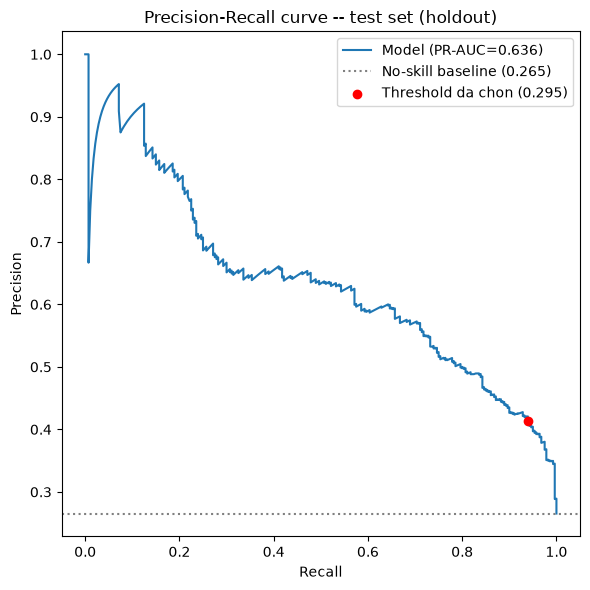

In [6]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, test_proba)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(recall, precision, label=f"Model (PR-AUC={test_pr_auc:.3f})")
ax.axhline(y_test.mean(), color="gray", linestyle=":", label=f"No-skill baseline ({y_test.mean():.3f})")

# Danh dau diem tren duong cong tuong ung voi chosen_threshold
idx_closest = np.abs(pr_thresholds - chosen_threshold).argmin()
ax.scatter(
    recall[idx_closest], precision[idx_closest], color="red", zorder=5,
    label=f"Threshold da chon ({chosen_threshold:.3f})",
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve -- test set (holdout)")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Confusion Matrix — so sánh threshold đã chọn vs threshold mặc định 0.5

Minh họa cụ thể giá trị của việc tune threshold theo F2 thay vì dùng mặc định: ở threshold 0.5, model thiên
về precision (đúng bản chất khi train với `class_weight`/`scale_pos_weight` nhưng chưa điều chỉnh điểm cắt);
threshold đã chọn nghiêng nhiều hơn về recall — đúng định hướng "FN đắt hơn FP" đã chốt ở Pha 1.


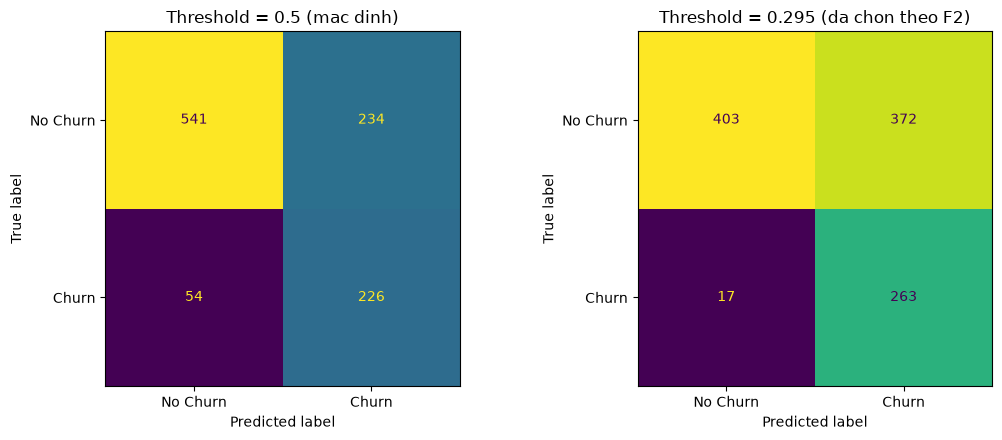

In [7]:
test_pred_default = (test_proba >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, title in [
    (axes[0], test_pred_default, "Threshold = 0.5 (mac dinh)"),
    (axes[1], test_pred, f"Threshold = {chosen_threshold:.3f} (da chon theo F2)"),
]:
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()


In [8]:
print(f"Classification report tai threshold = {chosen_threshold:.3f}:")
print(classification_report(y_test, test_pred, target_names=["No Churn", "Churn"]))


Classification report tai threshold = 0.295:
              precision    recall  f1-score   support

    No Churn       0.96      0.52      0.67       775
       Churn       0.41      0.94      0.57       280

    accuracy                           0.63      1055
   macro avg       0.69      0.73      0.62      1055
weighted avg       0.81      0.63      0.65      1055



## 6. Overfitting check — Train vs CV vs Test


In [9]:
train_proba_selfscore = final_pipeline.predict_proba(X_train)[:, 1]
train_pr_auc_selfscore = average_precision_score(y_train, train_proba_selfscore)

overfit_summary = pd.DataFrame(
    {
        "stage": ["Train (tu-danh-gia, model da thay du lieu nay)", "CV mean (Pha 3, out-of-fold)", "Test (holdout, chua tung thay)"],
        "PR-AUC": [train_pr_auc_selfscore, CV_PR_AUC_PHA3_MEAN, test_pr_auc],
    }
)
overfit_summary


,stage,PR-AUC
0,"Train (tu-danh-gia, model da thay du lieu nay)",0.699248
1,"CV mean (Pha 3, out-of-fold)",0.676800
2,"Test (holdout, chua tung thay)",0.636478


Nếu `Train` cao hơn hẳn `CV mean`, đó là mức overfit đã biết từ Pha 3 (overfit_gap = 0.0257 cho CatBoost
tuned) — không có gì mới. Điều cần nhìn là khoảng cách **CV mean vs Test**: đây là bằng chứng thực nghiệm
đầu tiên (và duy nhất) rằng quy trình CV ở Pha 3 dự đoán đúng hiệu năng trên dữ liệu hoàn toàn mới.


## 7. Error analysis

Trích các dòng bị dự đoán sai trên test set (ở `chosen_threshold`), đối chiếu với các nhóm dự đoán đúng để
tìm pattern lỗi — không chỉ nhìn con số tổng hợp.


In [10]:
results_df = test_df.copy()
results_df["churn_proba"] = test_proba
results_df["predicted"] = test_pred
results_df["actual"] = y_test.values


def outcome(row):
    if row["actual"] == 1 and row["predicted"] == 1:
        return "TP"
    if row["actual"] == 0 and row["predicted"] == 0:
        return "TN"
    if row["actual"] == 0 and row["predicted"] == 1:
        return "FP"
    return "FN"


results_df["outcome"] = results_df.apply(outcome, axis=1)
results_df["outcome"].value_counts()


outcome
TN    403
FP    372
TP    263
FN     17
Name: count, dtype: int64

**FN (False Negative) — nhóm quan trọng nhất**: khách hàng thực sự rời đi nhưng model bỏ sót — đúng loại lỗi
đắt nhất theo cost matrix đã chốt ở Pha 1. So sánh đặc điểm của nhóm này với TP (khách churn model bắt đúng)
để xem model đang bỏ sót kiểu khách hàng nào.


In [11]:
compare_cols_numeric = ["tenure", "MonthlyCharges", "TotalCharges", "churn_proba"]
fn_vs_tp = results_df[results_df["outcome"].isin(["FN", "TP"])].groupby("outcome")[compare_cols_numeric].median()
fn_vs_tp


,tenure,MonthlyCharges,TotalCharges,churn_proba
outcome,,,,
FN,40.0,67.50,2896.40,0.201287
TP,9.0,78.05,573.75,0.756116


In [12]:
for col in ["Contract", "InternetService", "PaymentMethod"]:
    print(f"--- {col} ---")
    print(
        pd.crosstab(results_df[results_df["outcome"].isin(["FN", "TP"])]["outcome"], results_df[col], normalize="index").round(3)
    )
    print()


--- Contract ---
Contract  Month-to-month  One year  Two year
outcome                                     
FN                 0.176     0.529     0.294
TP                 0.924     0.076     0.000

--- InternetService ---
InternetService    DSL  Fiber optic     No
outcome                                   
FN               0.706        0.235  0.059
TP               0.205        0.734  0.061

--- PaymentMethod ---
PaymentMethod  Bank transfer (automatic)  Credit card (automatic)  \
outcome                                                             
FN                                 0.294                    0.294   
TP                                 0.148                    0.118   

PaymentMethod  Electronic check  Mailed check  
outcome                                        
FN                        0.176         0.235  
TP                        0.563         0.171  



**FP (False Positive) — nhóm tốn chi phí ưu đãi lãng phí**: khách trung thành nhưng bị gắn cờ rủi ro. So
sánh với TN (khách trung thành model nhận diện đúng).


In [13]:
fp_vs_tn = results_df[results_df["outcome"].isin(["FP", "TN"])].groupby("outcome")[compare_cols_numeric].median()
fp_vs_tn


,tenure,MonthlyCharges,TotalCharges,churn_proba
outcome,,,,
FP,18.0,75.375,1219.90,0.572855
TN,51.0,47.850,1766.75,0.075316


## 7b. Đi sâu vào từng dòng trong 17 khách hàng FN

Giữ nguyên `chosen_threshold` (không đổi β/threshold ở bước này). Xem từng dòng cụ thể, không chỉ median
gộp nhóm — phân biệt hai loại lỗi rất khác nhau về ý nghĩa: model **suýt bắt được** (`churn_proba` gần
`chosen_threshold`, chỉ cần lệch một chút là đã đúng) so với model **tự tin sai hoàn toàn** (`churn_proba`
rất thấp, model không hề nghi ngờ khách này) — hai loại này cần hướng khắc phục khác nhau: loại đầu là vấn
đề threshold/độ nhiễu, loại sau là vấn đề model thiếu tín hiệu/feature để nhận ra pattern.


In [14]:
fn_detail_cols = [
    "customerID",
    "churn_proba",
    "tenure",
    "Contract",
    "InternetService",
    "MonthlyCharges",
    "TotalCharges",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling",
]
fn_detail = results_df[results_df["outcome"] == "FN"][fn_detail_cols].sort_values(
    "churn_proba", ascending=False
).reset_index(drop=True)
fn_detail


,customerID,churn_proba,tenure,Contract,InternetService,MonthlyCharges,TotalCharges,PaymentMethod,OnlineSecurity,TechSupport,PaperlessBilling
0,2165-VOEGB,0.280730,46,One year,Fiber optic,105.20,4822.85,Bank transfer (automatic),Yes,Yes,Yes
1,6682-QJDGB,0.270361,40,Month-to-month,DSL,55.25,2139.20,Mailed check,Yes,No,Yes
2,9378-FXTIZ,0.262920,54,One year,DSL,70.15,3715.65,Credit card (automatic),No,No,Yes
3,2533-QVMSK,0.251505,61,Two year,Fiber optic,94.10,5638.30,Electronic check,No,Yes,Yes
4,9039-RBEEE,0.245132,39,Month-to-month,DSL,48.95,1880.85,Credit card (automatic),Yes,Yes,Yes
5,2930-UOTMB,0.238771,31,Month-to-month,DSL,65.25,1994.30,Credit card (automatic),Yes,Yes,No
6,7666-WKRON,0.235848,39,Two year,Fiber optic,80.45,3201.55,Electronic check,No,Yes,Yes
7,4785-QRJHC,0.222154,46,One year,DSL,59.90,2816.65,Bank transfer (automatic),No,Yes,Yes
8,5271-YNWVR,0.201287,68,Two year,Fiber optic,113.15,7856.00,Electronic check,Yes,Yes,Yes
9,3594-UVONA,0.196389,35,One year,DSL,85.95,3110.10,Credit card (automatic),Yes,Yes,Yes


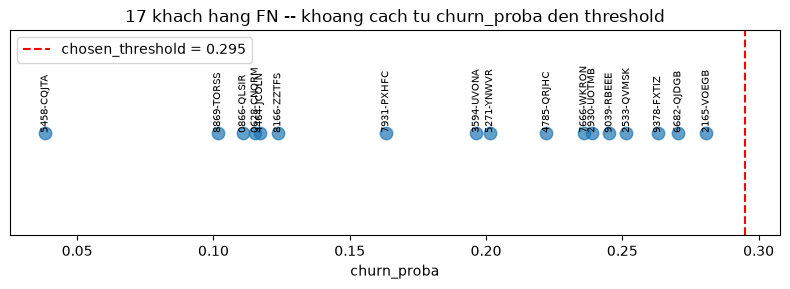

In [15]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(fn_detail["churn_proba"], np.zeros(len(fn_detail)), s=80, alpha=0.7)
ax.axvline(chosen_threshold, color="red", linestyle="--", label=f"chosen_threshold = {chosen_threshold:.3f}")
for _, row in fn_detail.iterrows():
    ax.annotate(row["customerID"], (row["churn_proba"], 0), rotation=90, fontsize=7, ha="center", va="bottom")
ax.set_yticks([])
ax.set_xlabel("churn_proba")
ax.set_title("17 khach hang FN -- khoang cach tu churn_proba den threshold")
ax.legend()
plt.tight_layout()
plt.show()


In [16]:
NEAR_MISS_RATIO = 0.7  # churn_proba >= 70% cua chosen_threshold duoc coi la "near-miss"
fn_detail["category"] = np.where(
    fn_detail["churn_proba"] >= chosen_threshold * NEAR_MISS_RATIO,
    "Near-miss (gan nguong)",
    "Confident miss (model rat tu tin sai)",
)
fn_detail["category"].value_counts()


category
Confident miss (model rat tu tin sai)    9
Near-miss (gan nguong)                   8
Name: count, dtype: int64

**Near-miss** (`churn_proba` từ 70% threshold trở lên): model đã "nghi ngờ" đúng hướng, chỉ chưa đủ tự
tin để vượt ngưỡng — đây là nhiễu tự nhiên của model, không phải model bị mù hoàn toàn với nhóm khách này.

**Confident miss**: model gần như chắc chắn (sai) rằng khách này sẽ ở lại — đáng quan tâm hơn nhiều, vì đây
là dấu hiệu model **thiếu tín hiệu/feature** để nhận diện đúng pattern, không phải vấn đề chọn threshold.
Nhìn kỹ nhóm này ở bảng chi tiết phía trên: nếu họ có `tenure` dài, `Contract` One/Two year, `TechSupport`/
`OnlineSecurity` = Yes (tức "trông rất trung thành" theo mọi tín hiệu hiện có trong dataset) mà vẫn rời đi —
đó là bằng chứng khá rõ rằng **nguyên nhân churn thật của nhóm này nằm ngoài phạm vi feature hiện có** (ví
dụ: giá tăng lúc gia hạn hợp đồng, đối thủ cạnh tranh chào giá tốt hơn, một sự cố dịch vụ cụ thể không được
ghi nhận trong dataset) — không phải lỗi có thể sửa bằng cách tune model/threshold thêm nữa, mà là giới hạn
của chính bộ dữ liệu.


## 8. Tổng kết Pha 4 & toàn bộ CRISP-ML(Q) cycle

- Model cuối: CatBoost (tuned), threshold vận hành = giá trị đã chọn ở mục 2 (tối ưu F2 trên OOF train pool).
- Test set performance đã báo cáo ở mục 3 là con số duy nhất, không bị chọn lọc/nhìn lại nhiều lần.
- Error analysis ở mục 7 cho biết model đang bỏ sót/gắn cờ nhầm kiểu khách hàng nào — input cho vòng cải
  tiến tiếp theo (feature engineering mới, hoặc thu thập thêm dữ liệu) nếu muốn đi xa hơn.
- **Theo đúng phạm vi đã thống nhất từ đầu: MLflow/experiment tracking/monitoring không nằm trong giai đoạn
  này** — đây là điểm dừng của baseline + experiment vững chắc, sẵn sàng cho bước tiếp theo khi cần.
